In [5]:
import matplotlib.pyplot as plt
import sys

import awkward as ak

import uproot
import numpy as np

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema

from coffea.analysis_tools import PackedSelection

In [2]:
file_list = [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] + [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]

NanoAODSchema.warn_missing_crossrefs = False

events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list},
    schemaclass=NanoAODSchema,
    metadata={"dataset": "DYJets"},
).events()

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[0:4]},
    schemaclass=NanoAODSchema,
    metadata={"dataset": "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"},
).events()

#uproot.concatenate(file_list)

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/coffea/nanoevents/methods/candidate.py:11: FutureWarning: In version 2024.7.0 (target date: 2024-06-30 11:59:59-05:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


Text(0.5, 0, 'Number of Charged Leptons Per Event')

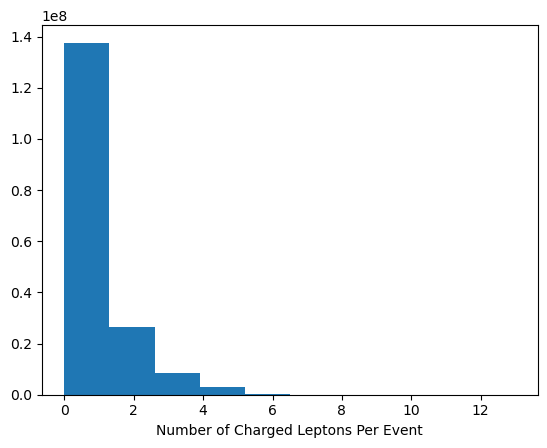

In [40]:
plt.hist(np.add(ak.count(events.ScoutingMuon.pt.compute(),axis=1), ak.count(events.ScoutingElectron.pt.compute(),axis=1)))

plt.xlabel("Number of Charged Leptons Per Event")

Text(0.5, 0, 'Number of Jets Per Event')

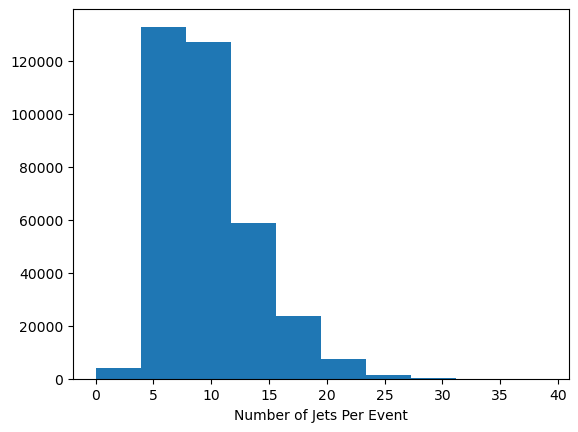

In [26]:
plt.hist(ak.count(small_events.ScoutingJet.pt.compute(),axis=1))

plt.xlabel("Number of Jets Per Event")

In [45]:
small_events.ScoutingJet.pt.compute()

<Array [[0, 1, 2, 3], ..., [1, 0, ..., -99999]] type='355872 * var * int32[...'>

In [42]:
small_events.GenJet.partonFlavour.compute()

<Array [[-5, 5, -3, -4, 4, 3], ..., [5, ...]] type='355872 * var * int16[pa...'>

In [8]:
selection = PackedSelection()

selection.add("OneB", ak.sum(events.GenJet.partonFlavour == 5, axis=1) == 1)
selection.add("OneC", ak.sum(events.GenJet.partonFlavour == 4, axis=1) == 1)
selection.add("OneS", ak.sum(events.GenJet.partonFlavour == 3, axis=1) == 1)
selection.add("OneAB", ak.sum(events.GenJet.partonFlavour == -5, axis=1) == 1)
selection.add("OneAC", ak.sum(events.GenJet.partonFlavour == -4, axis=1) == 1)
selection.add("OneAS", ak.sum(events.GenJet.partonFlavour == -3, axis=1) == 1)

selection.names


['OneB', 'OneC', 'OneS', 'OneAB', 'OneAC', 'OneAS']

Text(0.5, 0, 'Mass of b + c + s GenJets [GeV]')

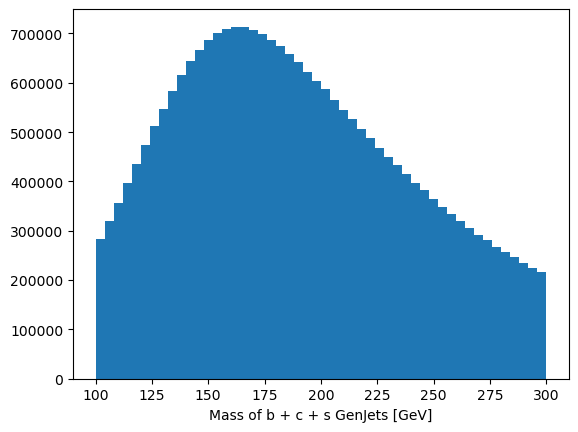

In [10]:
m_events = events[selection.all("OneB", "OneC", "OneS")]

bj = m_events.GenJet[m_events.GenJet.partonFlavour == 5]
cj = m_events.GenJet[m_events.GenJet.partonFlavour == 4]
sj = m_events.GenJet[m_events.GenJet.partonFlavour == 3]


top = bj + cj + sj
plt.hist(top.mass.compute(),
         range = (100, 300),
         bins= 50)

plt.xlabel("Mass of b + c + s GenJets [GeV]")

Text(0.5, 0, 'Mass of b + c + as GenJets [GeV]')

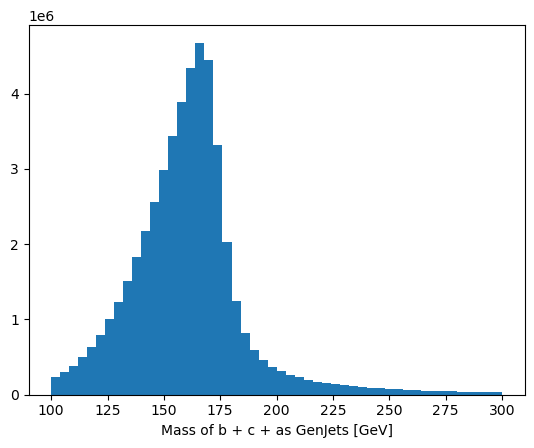

In [12]:
m_events = events[selection.all("OneB", "OneC", "OneAS")]

bj = m_events.GenJet[m_events.GenJet.partonFlavour == 5]
cj = m_events.GenJet[m_events.GenJet.partonFlavour == 4]
asj = m_events.GenJet[m_events.GenJet.partonFlavour == -3]


top = bj + cj + asj
plt.hist(top.mass.compute(),
         range = (100, 300),
         bins= 50)

plt.xlabel("Mass of b + c + as GenJets [GeV]")